#### Assignment 1: Random Projections

> *Course: Machine Learning 2*

> *Prof: Jan Nagler*

> *Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang*

In [1]:
# Importing necessary libraries
from sklearn.random_projection import SparseRandomProjection
from sklearn.random_projection import johnson_lindenstrauss_min_dim
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import warnings
import io, urllib,os
import zipfile
from PIL import Image
warnings.filterwarnings('ignore')
%matplotlib inline
np.random.seed(42)  

#### A. Columbia Object Image Library dataset (COIL-20)

Description:

- It contains 1440 grayscale images of 20 objects each photographed from 72 different rotation angles.
- `128x128` pixels giving `16,384` features per image.
- Images live in Euclidean space, where pixel to pixel distance is a valid similarity measure and is suitable for random projections.


**1. Loading the dataset**

In [2]:
# Downloading the COIL-20 dataset
response = urllib.request.urlopen('http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip')
zip_bytes = io.BytesIO(response.read())
X_coil, y_coil = [], []
with zipfile.ZipFile(zip_bytes) as zf:
    for fname in sorted(zf.namelist()):
        if fname.endswith('.png'):
            label = int(fname.split('obj')[1].split('_')[0]) - 1
            img_bytes = io.BytesIO(zf.read(fname))
            img = Image.open(img_bytes).convert('L')
            X_coil.append(np.array(img).flatten().astype('float32') / 255.0)
            y_coil.append(label)
X_coil = np.array(X_coil)
y_coil = np.array(y_coil)
print('COIL-20 shape:', X_coil.shape)
print('Number of classes:', len(np.unique(y_coil)))

COIL-20 shape: (1440, 16384)
Number of classes: 20


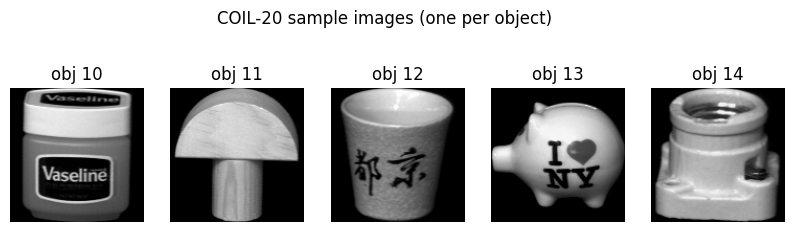

In [3]:
# Displaying some sample images from the dataset
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_coil[i * 72].reshape(128, 128), cmap='gray')
    ax.set_title('obj %d' % (y_coil[i * 72] + 1))
    ax.axis('off')
plt.suptitle('COIL-20 sample images (one per object)')
plt.show()

In [4]:
# Splitting the dataset into training and testing sets (70% train, 30% test)
X_coil_train, X_coil_test, y_coil_train, y_coil_test = train_test_split(X_coil, y_coil, test_size=0.3, random_state=42)
print('Train size:', X_coil_train.shape)
print('Test size: ', X_coil_test.shape)
print('Feature dimension (original):', X_coil_train.shape[1])

Train size: (1008, 16384)
Test size:  (432, 16384)
Feature dimension (original): 16384


**2. Johnson and Lindenstrauss Bound**

In [5]:
# Johnson-Lidenstrauss bound for COIL-20 (eps=0.1)
# For n=1440 samples, dimension d=128x128=16384 (pixels)
print('Professors Johnson and Lindenstrauss say: k >=',johnson_lindenstrauss_min_dim(len(X_coil), eps=0.1))

Professors Johnson and Lindenstrauss say: k >= 6233


**3. Getting baseline accuracy** 

In [6]:
model_coil=LinearSVC(random_state=42,max_iter=2000)
model_coil.fit(X_coil_train, y_coil_train)
baseline_coil=metrics.accuracy_score(y_coil_test, model_coil.predict(X_coil_test))
print('Baseline accuracy (no projection): %.4f' % baseline_coil)

Baseline accuracy (no projection): 0.9907


**4. Sparse Random Projection**

In [7]:
# Applying sparse random projection for varying dimensions
accuracies_coil = []
dims_coil = np.int32(np.linspace(2, 500, 20))
for dim in dims_coil:
    sp = SparseRandomProjection(n_components=dim, random_state=42)
    X_proj = sp.fit_transform(X_coil_train)
    model = LinearSVC(max_iter=2000)
    model.fit(X_proj, y_coil_train)
    test_proj = sp.transform(X_coil_test)
    accuracies_coil.append(metrics.accuracy_score(y_coil_test, model.predict(test_proj)))

**5. Ensembled Random Projection**

In [8]:
# Applying ensembled sparse random projection over multiple realizations
n_realizations = 25
accuracies_coil_ens = np.zeros((n_realizations, len(dims_coil)))
for j, dim in enumerate(dims_coil):
    for i in range(n_realizations):
        sp = SparseRandomProjection(n_components=dim)
        X_proj = sp.fit_transform(X_coil_train)
        model = LinearSVC(max_iter=2000)
        model.fit(X_proj, y_coil_train)
        test_proj = sp.transform(X_coil_test)
        accuracies_coil_ens[i, j] = metrics.accuracy_score(y_coil_test, model.predict(test_proj))
# Averaging across realizations
avg_accuracies_coil = accuracies_coil_ens.mean(axis=0)

**6. Plotting Sparse Random Projection and Ensembled random projection**

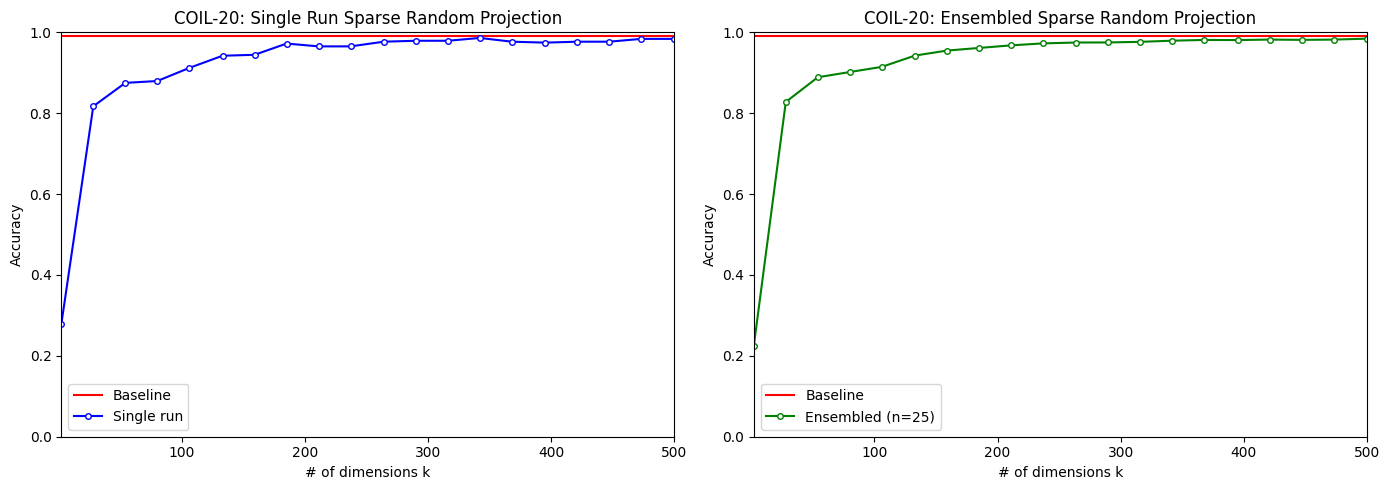

In [9]:
# Plotting single run sparse random projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[0].plot(dims_coil, accuracies_coil, color='b', label='Single run',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[0].set_xlabel('# of dimensions k')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('COIL-20: Single Run Sparse Random Projection')
axes[0].set_xlim([2, 500])
axes[0].set_ylim([0, 1])
axes[0].legend()
# Plotting ensembled sparse random projection
axes[1].plot(dims_coil, [baseline_coil] * len(dims_coil), color='r', label='Baseline')
axes[1].plot(dims_coil, avg_accuracies_coil, color='g', label='Ensembled (n=25)',marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1)
axes[1].set_xlabel('# of dimensions k')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('COIL-20: Ensembled Sparse Random Projection')
axes[1].set_xlim([2, 500])
axes[1].set_ylim([0, 1])
axes[1].legend()
plt.tight_layout()
plt.show()

**Conclusion for Dataset 1**
- The baseline accuracy without any projection is `0.9907` (99.07%), computed using a LinearSVC on the full 16,384-dimensional space.
- The *single run curve* shows **slight dips and bumps (around k = 150) due to the randomness of individual projections**.
- The *ensembled curve* (25 realizations averaged) is **visibly smoother, confirming that averaging over multiple random projections removes variance caused by any single projection matrix.**
- Also, near baseline accuracy (~99%) is recovered at roughly k=300-400 dimensions far below the JL bound of 6233, suggesting the bound is highly conservative for this dataset.

#### B. {Name of the dataset}

Description:

-
-


In [10]:
# Displaying some sample images from the dataset

**2. Johnson and Lindenstrauss Bound**

**3. Getting baseline accuracy** 

**4. Sparse Random Projection**

**5. Ensembled Random Projection**

**6. Plotting Sparse Random Projection and Ensembled random projection**

#### Comparing 'Dataset 1' and 'Dataset 2'

In [11]:
# Graph comparison

#### Conclusion:

-
-
